### Assignment 1

#### Dataset link : https://www.kaggle.com/datasets/dgomonov/new-york-city-airbnb-open-data

In [1]:
#Importing the libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#Loading the dataset using pandas library
df = pd.read_csv("AB_NYC_2019.csv")
df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [3]:
#Checking shape of the dataset
df.shape

(48895, 16)

In [4]:
#Getting all the column names
df.columns.tolist()

['id',
 'name',
 'host_id',
 'host_name',
 'neighbourhood_group',
 'neighbourhood',
 'latitude',
 'longitude',
 'room_type',
 'price',
 'minimum_nights',
 'number_of_reviews',
 'last_review',
 'reviews_per_month',
 'calculated_host_listings_count',
 'availability_365']

In [5]:
#Checking datatype of every column
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     

In [6]:
#Changing the datatype of last_review from int64 to datetime as it is a date column
df['last_review'] = pd.to_datetime(df['last_review'])

In [7]:
#getting the no. of nulls in every column
df.isna().sum()

id                                    0
name                                 16
host_id                               0
host_name                            21
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10052
reviews_per_month                 10052
calculated_host_listings_count        0
availability_365                      0
dtype: int64

In [8]:
#As there are less number of rows with missing values for name and host_name therefore replacing this missing rows with unknowns
df['name'] = df['name'].fillna('Unknown')
df['host_name'] = df['host_name'].fillna('Unknown')

In [9]:
#checking again
df.isna().sum()

id                                    0
name                                  0
host_id                               0
host_name                             0
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10052
reviews_per_month                 10052
calculated_host_listings_count        0
availability_365                      0
dtype: int64

In [10]:
#Filling the review with 0 as many of them are left without leaving any review
df['reviews_per_month'] = df['reviews_per_month'].fillna(0)

In [11]:
#Checking the value where the last_review date is null and number_of_reviews is unique
df.loc[df['last_review'].isna(), 'number_of_reviews'].unique()

array([0], dtype=int64)

##There are None so we can say it has not received any review

In [12]:
#Dropping the last_review column as it has not much of a significance in our data
df.drop('last_review', axis=1, inplace=True)

In [13]:
#checking the statistical values for the data
df.shape

(48895, 15)

In [14]:
#We can see the minimum value for price is 0 
#checking 0th price
df[df['price'] == 0]

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
23161,18750597,"Huge Brooklyn Brownstone Living, Close to it all.",8993084,Kimberly,Brooklyn,Bedford-Stuyvesant,40.69023,-73.95428,Private room,0,4,1,0.05,4,28
25433,20333471,★Hostel Style Room | Ideal Traveling Buddies★,131697576,Anisha,Bronx,East Morrisania,40.83296,-73.88668,Private room,0,2,55,2.56,4,127
25634,20523843,"MARTIAL LOFT 3: REDEMPTION (upstairs, 2nd room)",15787004,Martial Loft,Brooklyn,Bushwick,40.69467,-73.92433,Private room,0,2,16,0.71,5,0
25753,20608117,"Sunny, Quiet Room in Greenpoint",1641537,Lauren,Brooklyn,Greenpoint,40.72462,-73.94072,Private room,0,2,12,0.53,2,0
25778,20624541,Modern apartment in the heart of Williamsburg,10132166,Aymeric,Brooklyn,Williamsburg,40.70838,-73.94645,Entire home/apt,0,5,3,0.15,1,73
25794,20639628,Spacious comfortable master bedroom with nice ...,86327101,Adeyemi,Brooklyn,Bedford-Stuyvesant,40.68173,-73.91342,Private room,0,1,93,4.28,6,176
25795,20639792,Contemporary bedroom in brownstone with nice view,86327101,Adeyemi,Brooklyn,Bedford-Stuyvesant,40.68279,-73.91170,Private room,0,1,95,4.37,6,232
25796,20639914,Cozy yet spacious private brownstone bedroom,86327101,Adeyemi,Brooklyn,Bedford-Stuyvesant,40.68258,-73.91284,Private room,0,1,95,4.35,6,222
26259,20933849,the best you can find,13709292,Qiuchi,Manhattan,Murray Hill,40.75091,-73.97597,Entire home/apt,0,3,0,0.00,1,0
26841,21291569,Coliving in Brooklyn! Modern design / Shared room,101970559,Sergii,Brooklyn,Bushwick,40.69211,-73.90670,Shared room,0,30,2,0.11,6,333


In [15]:
#Price can't be zero so dropping all the columns with Price 0
df = df[df['price'] != 0]

In [16]:
df.shape

(48884, 15)

In [17]:
#Checking for the listings with very high price
df[df['price'] >= 1000].sort_values('price', ascending=False)

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
17692,13894339,Luxury 1 bedroom apt. -stunning Manhattan views,5143901,Erin,Brooklyn,Greenpoint,40.73260,-73.95739,Entire home/apt,10000,5,5,0.16,1,0
29238,22436899,1-BR Lincoln Center,72390391,Jelena,Manhattan,Upper West Side,40.77213,-73.98665,Entire home/apt,10000,30,0,0.00,1,83
9151,7003697,Furnished room in Astoria apartment,20582832,Kathrine,Queens,Astoria,40.76810,-73.91651,Private room,10000,100,2,0.04,1,0
12342,9528920,"Quiet, Clean, Lit @ LES & Chinatown",3906464,Amy,Manhattan,Lower East Side,40.71355,-73.98507,Private room,9999,99,6,0.14,1,83
40433,31340283,2br - The Heart of NYC: Manhattans Lower East ...,4382127,Matt,Manhattan,Lower East Side,40.71980,-73.98566,Entire home/apt,9999,30,0,0.00,1,365
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40152,31149094,Tribeca Loft,273174,Jon,Manhattan,Tribeca,40.71943,-74.00435,Entire home/apt,1000,1,2,0.40,3,38
15833,12811459,Superhost-Designer Legal 4 Bed Townhouse Midto...,69852641,Lisa,Manhattan,Hell's Kitchen,40.76303,-73.98767,Entire home/apt,1000,2,24,0.71,3,274
3812,2297192,2BD/2BA Manhattan Apt,11732741,Bryce,Manhattan,Financial District,40.70825,-74.00495,Entire home/apt,1000,1,0,0.00,1,0
39766,30935679,Ashly’s apartment,231163395,Ashly,Manhattan,Harlem,40.82206,-73.93799,Private room,1000,30,0,0.00,1,90


In [18]:
df[df['price'] >= 1000].sort_values('price', ascending=False).shape


(298, 15)

In [19]:
# Counting duplicate rows
df.duplicated().sum()

0

In [20]:
#Checking for duplicate ids
df['id'].duplicated().sum()

0

In [21]:
#Checking for duplicate host_ids
df['host_id'].duplicated().sum()

11429

Duplicate host_id is not a problem as one host can have mupltiple listings

In [22]:
#Checking room_type for the rooms with very high values
df[df['price'] >= 1000]['room_type'].value_counts()


room_type
Entire home/apt    243
Private room        51
Shared room          4
Name: count, dtype: int64

We can see mostly rooms with high values are :Entire home/apt and private rooms

In [23]:
df.shape

(48884, 15)

### EDA

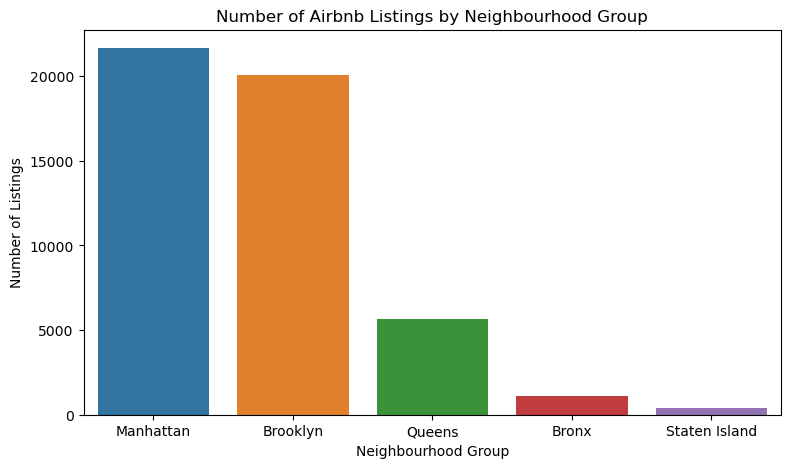

In [24]:
#Distribution of Airbnb Listings by Neighbourhood Group
plt.figure(figsize=(9, 5))

sns.countplot(
    data=df,
    x='neighbourhood_group',
    order=df['neighbourhood_group'].value_counts().index
)
plt.title('Number of Airbnb Listings by Neighbourhood Group')
plt.xlabel('Neighbourhood Group')
plt.ylabel('Number of Listings')

plt.show()

Airbnb listings are heavily concentrated in Manhattan and Brooklyn, indicating that these areas are the major Airbnb markets in New York City.

- Manhattan has the highest number of listings
- Brooklyn is second highest
- Staten Island has the fewest listings

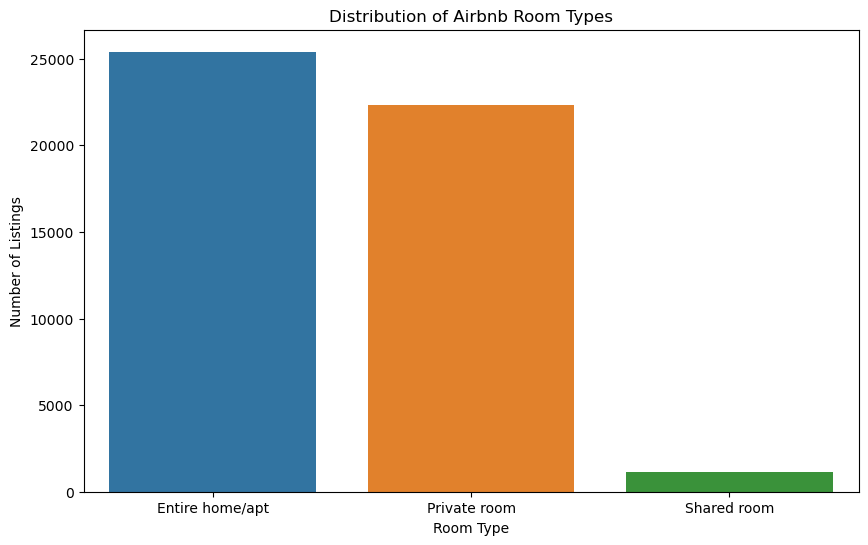

In [25]:
#Distribution of Room Types
plt.figure(figsize=(10, 6))

sns.countplot(
    data=df,
    x='room_type',
    order=df['room_type'].value_counts().index
)

plt.title('Distribution of Airbnb Room Types')
plt.xlabel('Room Type')
plt.ylabel('Number of Listings')

plt.show()

- Entire homes/apartments and private rooms dominate the Airbnb market, while shared rooms represent only a small proportion of listings.

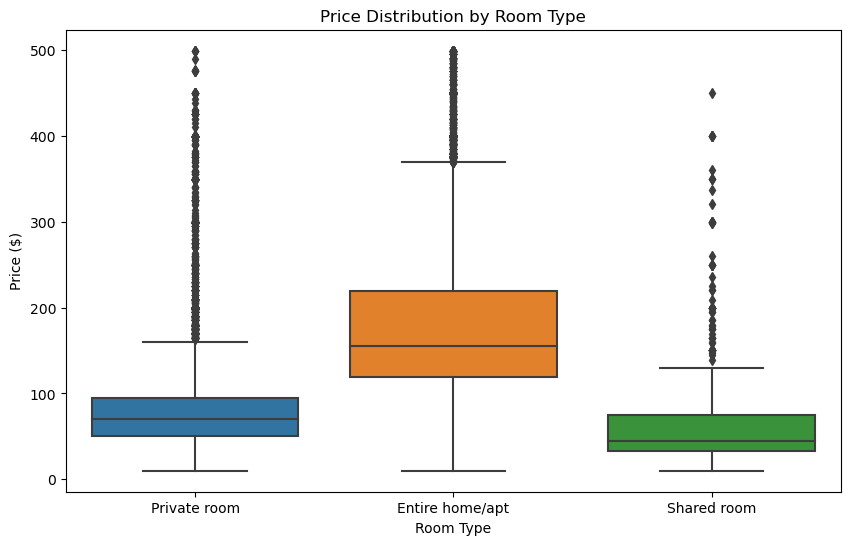

In [26]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df[df['price'] < 500],
    x='room_type',
    y='price'
)

plt.title('Price Distribution by Room Type')
plt.xlabel('Room Type')
plt.ylabel('Price ($)')

plt.show()

- Room type is an important determinant of Airbnb pricing. Entire homes and apartments generally command higher prices because guests receive exclusive access to the property.

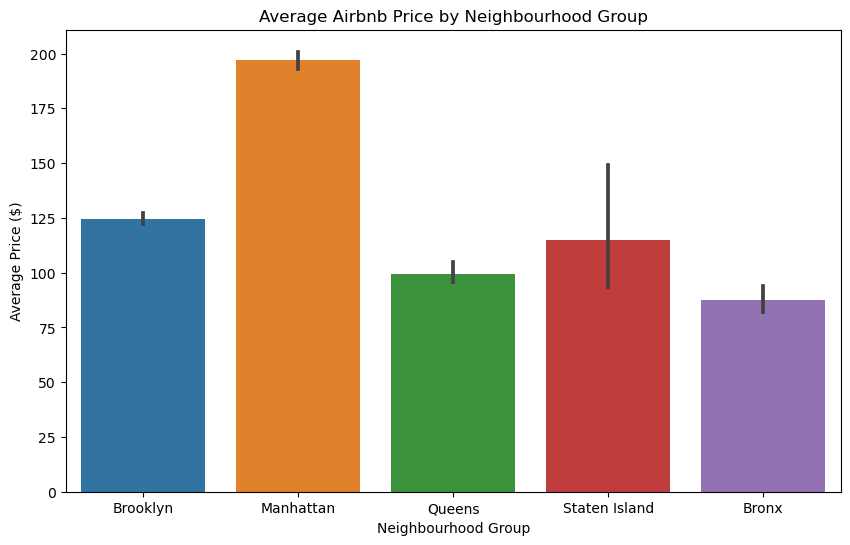

In [27]:
#Average Price by Neighbourhood Group
plt.figure(figsize=(10, 6))

sns.barplot(
    data=df,
    x='neighbourhood_group',
    y='price',
    estimator='mean'
)

plt.title('Average Airbnb Price by Neighbourhood Group')
plt.xlabel('Neighbourhood Group')
plt.ylabel('Average Price ($)')

plt.show()

- Manhattan among the most expensive
- Brooklyn & Staten Island are relatively expensive

- Location has a strong relationship with Airbnb pricing. Listings in central and high-demand areas tend to command higher prices.

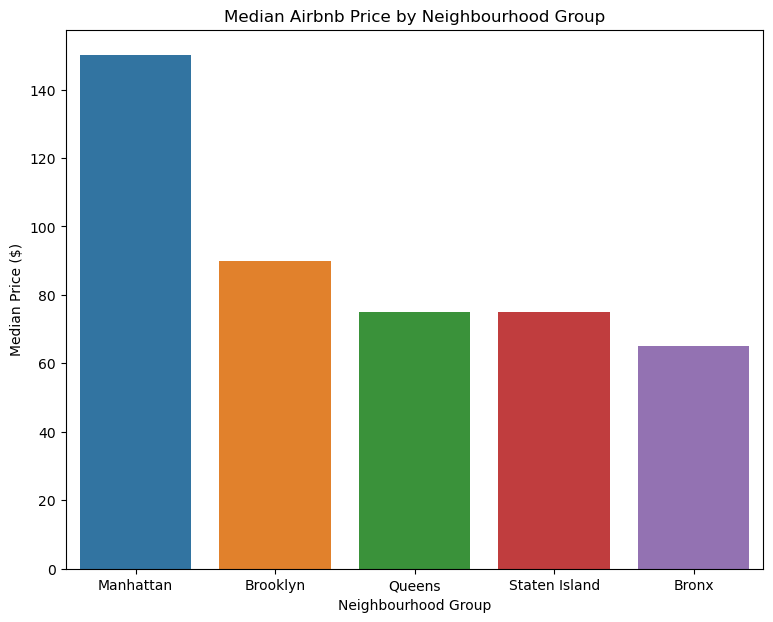

In [28]:
#checking by the median
#Median Price by Neighbourhood Group

median_price = (
    df.groupby('neighbourhood_group')['price'].median().sort_values(ascending=False)
)

plt.figure(figsize=(9, 7))
sns.barplot(
    x=median_price.index,
    y=median_price.values
)

plt.title('Median Airbnb Price by Neighbourhood Group')
plt.xlabel('Neighbourhood Group')
plt.ylabel('Median Price ($)')

plt.show()

- Expensive outliers are influencing the mean price for all the neighbourhoods

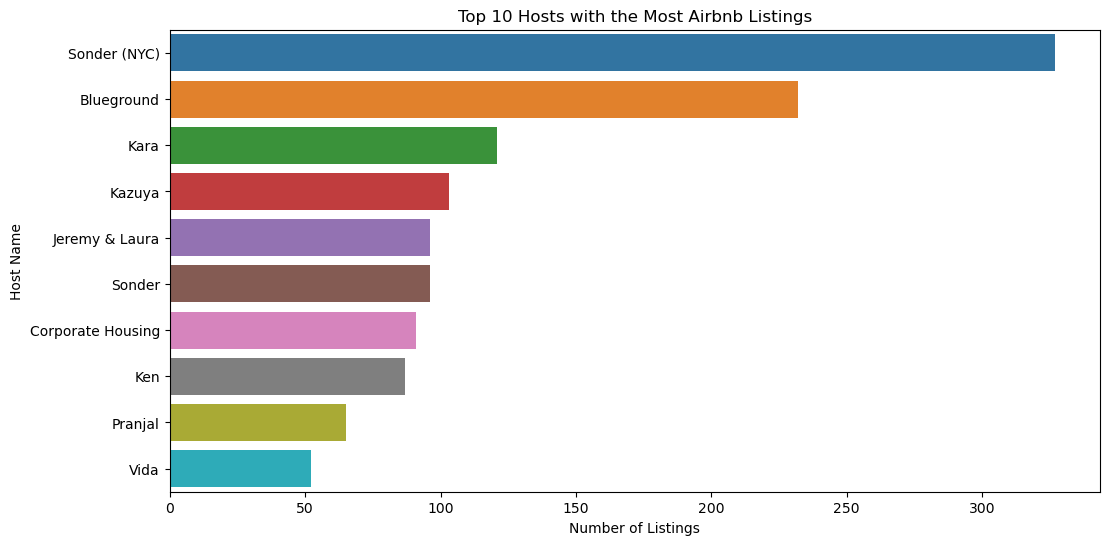

In [29]:
#Top 10 Hosts with the Most Airbnb Listings
top_hosts = (
    df.groupby(['host_id', 'host_name'])
      .size()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(12, 6))
sns.barplot(
    x=top_hosts.values,
    y=top_hosts.index.get_level_values('host_name')
)

plt.title('Top 10 Hosts with the Most Airbnb Listings')
plt.xlabel('Number of Listings')
plt.ylabel('Host Name')
plt.show()

- Some hosts operate very large portfolios, indicating substantial participation from professional property managers.

In [30]:
#Taking price as the target varibale
df['price'].describe(percentiles=[0.90, 0.95, 0.99])

count    48884.000000
mean       152.755053
std        240.170260
min         10.000000
50%        106.000000
90%        269.000000
95%        355.000000
99%        799.000000
max      10000.000000
Name: price, dtype: float64

- The price distribution is highly right-skewed. While the median listing price is 106 USD and 90% of listings are priced below 269 USD, the dataset contains extreme high-priced listings reaching up to 10,000 USD.
- These outliers significantly increase the mean price to approximately 153 USD and can distort visualizations and statistical analysis.

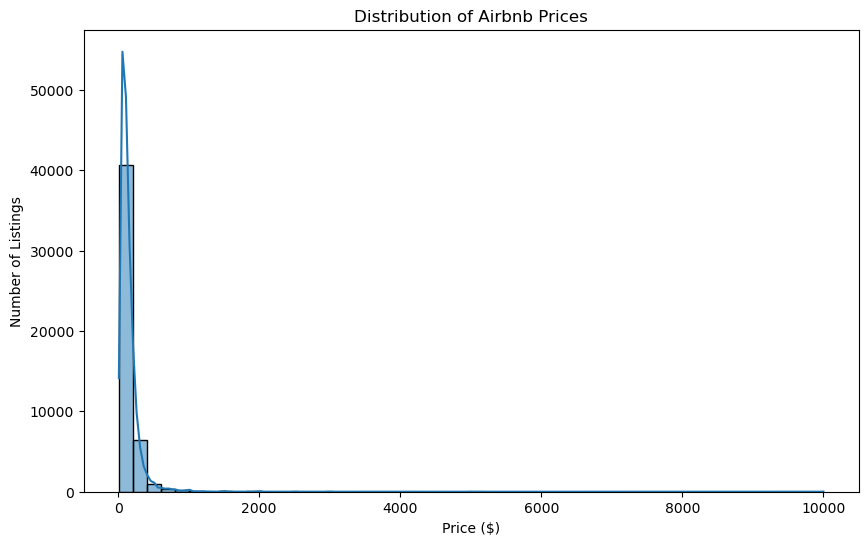

In [31]:
plt.figure(figsize=(10, 6))

sns.histplot(df['price'], bins=50, kde=True)

plt.title('Distribution of Airbnb Prices')
plt.xlabel('Price ($)')
plt.ylabel('Number of Listings')

plt.show()

- As the price curve is highly skewed therefore filtering for lower Price

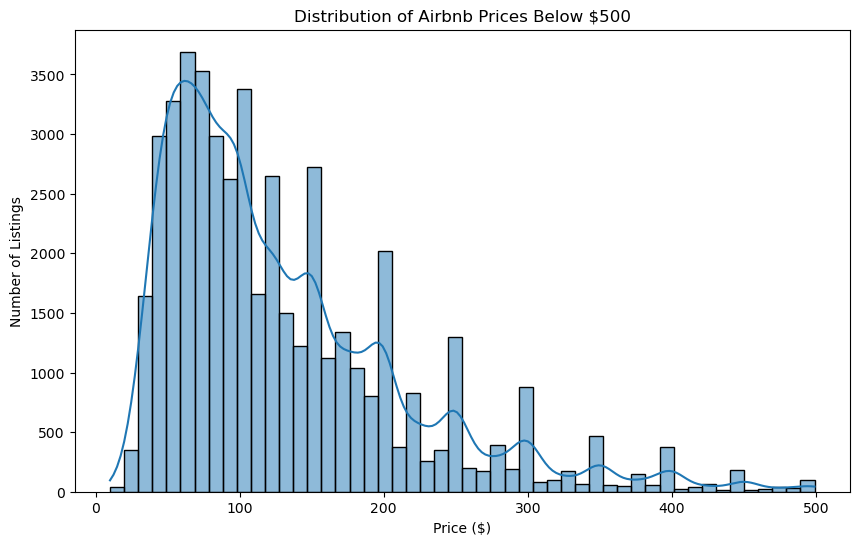

In [32]:
#Filtering all the listings with price < $500
plt.figure(figsize=(10, 6))

sns.histplot(
    df[df['price'] < 500]['price'],
    bins=50,
    kde=True
)

plt.title('Distribution of Airbnb Prices Below $500')
plt.xlabel('Price ($)')
plt.ylabel('Number of Listings')

plt.show()

- Most Airbnb listings are concentrated at lower and moderate price ranges, while a relatively small number of luxury properties create a long right tail.


In [33]:
#Checking for corelations among the numerical parameters
numerical_columns = [
    'latitude',
    'longitude',
    'price',
    'minimum_nights',
    'number_of_reviews',
    'reviews_per_month',
    'calculated_host_listings_count',
    'availability_365'
]

correlation = df[numerical_columns].corr()

In [34]:
correlation

,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
latitude,1.000000,0.084830,0.033899,0.024893,-0.015357,-0.018719,0.019518,-0.010942
longitude,0.084830,1.000000,-0.149954,-0.062772,0.059015,0.138435,-0.114715,0.082669
price,0.033899,-0.149954,1.000000,0.042805,-0.047926,-0.050531,0.057462,0.081847
minimum_nights,0.024893,-0.062772,0.042805,1.000000,-0.080080,-0.124870,0.127962,0.144275
number_of_reviews,-0.015357,0.059015,-0.047926,-0.080080,1.000000,0.589311,-0.072385,0.171975
reviews_per_month,-0.018719,0.138435,-0.050531,-0.124870,0.589311,1.000000,-0.047322,0.163664
calculated_host_listings_count,0.019518,-0.114715,0.057462,0.127962,-0.072385,-0.047322,1.000000,0.225712
availability_365,-0.010942,0.082669,0.081847,0.144275,0.171975,0.163664,0.225712,1.000000


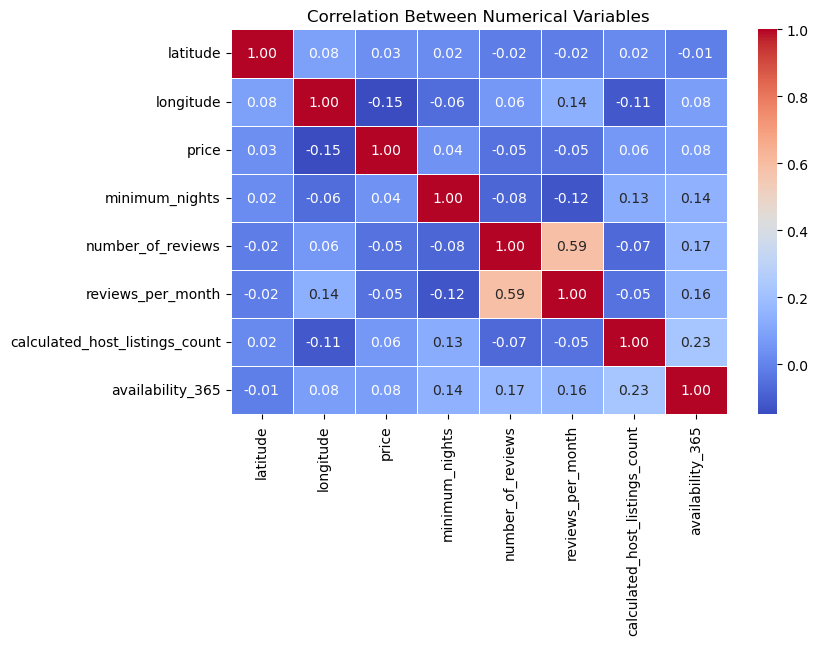

In [35]:
plt.figure(figsize=(8, 5))

sns.heatmap(
    correlation,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    linewidths=0.5
)

plt.title('Correlation Between Numerical Variables')

plt.show()

- Price does not have a strong linear relationship with any of the numerical variables shown in this heatmap.
- Numerical features alone may not be sufficient to explain or predict price well.
- More actively reviewed properties are likely to accumulate reviews at a higher monthly rate.

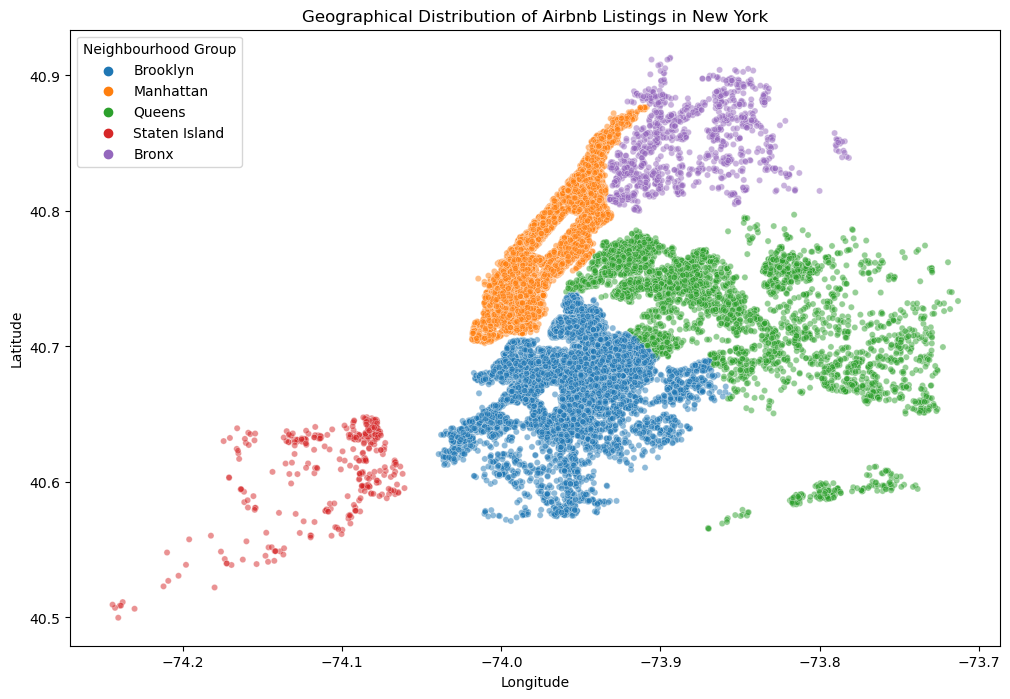

In [36]:
#Geographical Distribution of Airbnb Listings in New York
plt.figure(figsize=(12, 8))

sns.scatterplot(
    data=df,
    x='longitude',
    y='latitude',
    hue='neighbourhood_group',
    alpha=0.5,
    s=20
)

plt.title('Geographical Distribution of Airbnb Listings in New York')
plt.xlabel('Longitude')
plt.ylabel('Latitude')

plt.legend(title='Neighbourhood Group')

plt.show()

- Brooklyn and Manhattan show the highest concentration of listings, indicating that they are the most active Airbnb markets. Queens has a wider geographical distribution of properties, while the Bronx and Staten Island have comparatively fewer listings. The plot also confirms that latitude and longitude are useful features for understanding the spatial distribution of Airbnb properties.

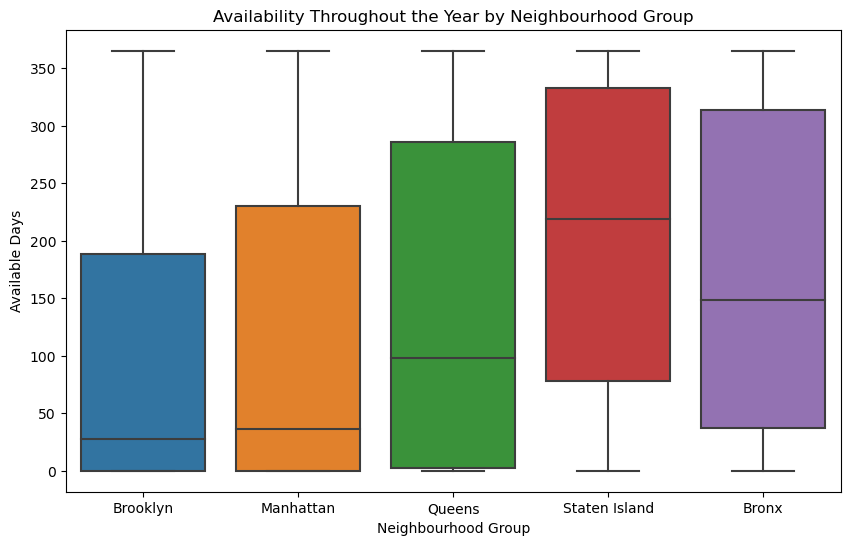

In [37]:
#Availability Throughout the Year by Neighbourhood Group
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x='neighbourhood_group',
    y='availability_365'
)

plt.title('Availability Throughout the Year by Neighbourhood Group')
plt.xlabel('Neighbourhood Group')
plt.ylabel('Available Days')
plt.show()

- Staten Island has the highest median availability, followed by the Bronx, while Brooklyn and Manhattan have the lowest median availability. Queens falls in the middle. The lower availability observed in Manhattan and Brooklyn may indicate higher booking activity

C:\Users\anjal\anaconda3\Lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


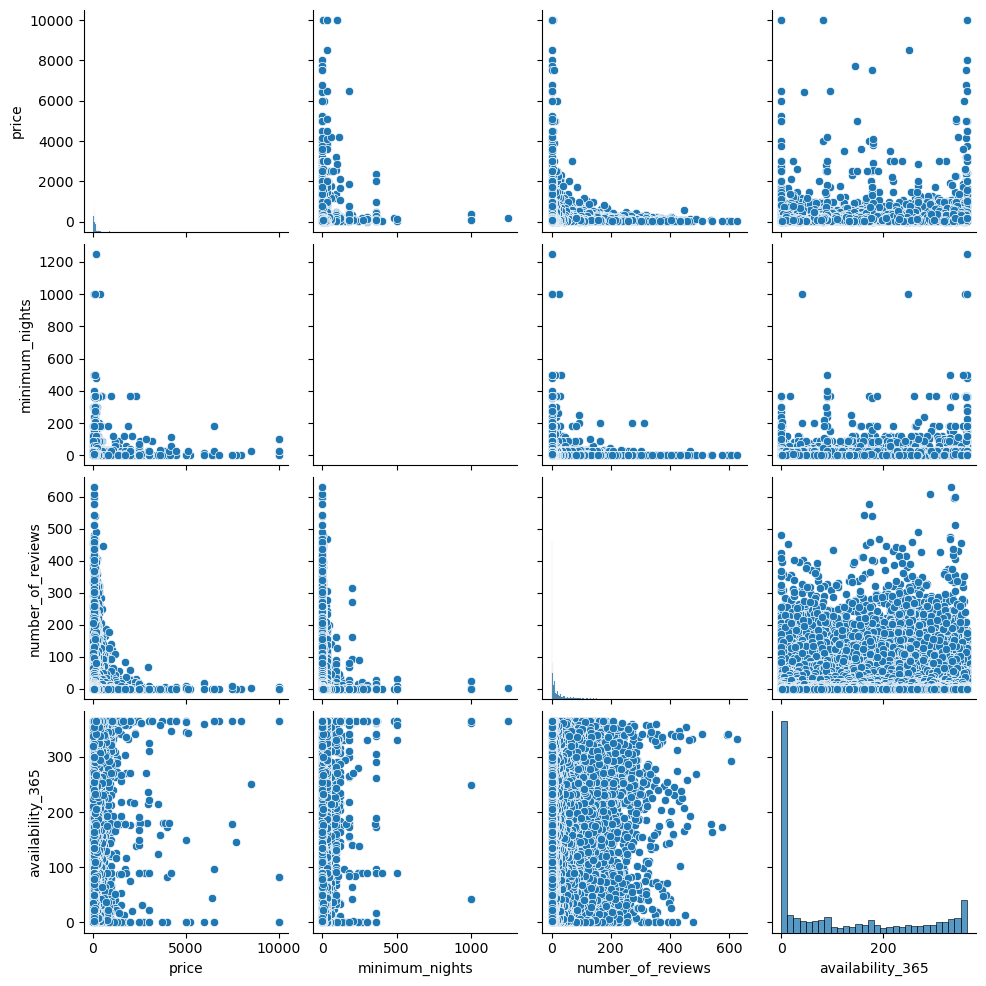

In [40]:
sns.pairplot(df[['price','minimum_nights','number_of_reviews','availability_365']])
plt.show()

- The pairplot analysis shows that price and minimum nights contain significant extreme values, resulting in highly skewed distributions. This is inline with the correlation study
- No strong linear relationship is observed between price and number of reviews, indicating that higher-priced listings do not necessarily receive more customer reviews.